# Resolución problema MMM a partir de su matriz QUBO

In [41]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import time


Loading BokehJS ...

# Definición de funciones para la resolución del grafo
1. `resolucion_clasica`: Obtiene la solución a lo bruto de forma clásica
2. `construir_geometria`: Establece la geometrías que codifica la matriz QUBO dada. Usa el algoritmo clásico Nelder-Mead
3. `resolver_qubo`: Emula el ordenador cuántico aportando la solución

In [42]:
    # Obtenemos la solución clásica por fuerza bruta
    def resolucion_clasica(Q_exacta, print_resultados = False):
        """
        Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO.
        verbose : bool       – Si True, imprime las mejores soluciones.

        Retorna
        -------
        sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
        """
        Q_exacta = np.array(Q_exacta)

        bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
        costs = []
        # this takes exponential time with the dimension of the QUBO
        for b in bitstrings:
            z = np.array(list(b), dtype=int)
            cost = z @ Q_exacta @ z
            costs.append(cost)
        zipped = zip(bitstrings, costs)
        sort_zipped = sorted(zipped, key=lambda x: x[1])

        if print_resultados:
            print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

        return sort_zipped
    # Ejecución de la función 
    #sort_zipped = resolucion_clasica(Q_exacta)


    # Determinamos la geometría de los átomos para Q
    def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
        """
        Optimiza las coordenadas atómicas para que las interacciones Rydberg
        reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO (simétrica).
        seed    : int        – Semilla para reproducibilidad.
        tol     : float      – Tolerancia del optimizador Nelder-Mead.
        maxiter : int        – Máximo de iteraciones.
        plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

        Retorna
        -------
        geometria : bloqade Program – Geometría lista para montar el programa.
        coords    : np.ndarray      – Coordenadas optimizadas (n×2).
        """
        Q = np.array(Q)
        device = pulser.DigitalAnalogDevice

        def evaluate_mapping(new_coords):
            new_coords = np.reshape(new_coords, (len(Q), 2))
            new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
            return np.linalg.norm(new_Q - Q)

        # Por si queremos cambiar el x0:
        if x0_func is not None:
            x0 = x0_func(A, Q)
        else:
            np.random.seed(seed)
            x0 = np.random.random(len(Q) * 2)

        #if random_x0 == True:
        #    np.random.seed(seed)
        #    x0 = np.random.random(len(Q) * 2)
        #elif random_x0 == False:
        #    C6 = 2 * np.pi * 862690
        #    d_init = (C6 / A) ** (1/6)
        #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init

        res = minimize(
            evaluate_mapping,
            x0,
            method="Nelder-Mead",
            tol=tol,
            options={"maxiter": maxiter, "maxfev": None},
        )

        coords = np.reshape(res.x, (len(Q), 2))

        if plot:
            # Visualización Pulser
            #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
            #reg = pulser.Register(coord_dict)
            #reg.draw(
            #    blockade_radius=device.rydberg_blockade_radius(1),
            #    draw_graph=False,
            #    draw_half_radius=True,
            #)
            coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
            reg = pulser.Register(coord_dict)
            # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
            omega_max = 0.9 * np.min(-np.diag(Q))
            reg.draw(
                blockade_radius=device.rydberg_blockade_radius(omega_max),
                draw_graph=False,
                draw_half_radius=True,
            )
            print(f"Coordenadas optimizadas:\n{coords}")

        # Construcción Bloqade
        coordenadas = [tuple(pt) for pt in coords.tolist()]
        geometria = start.add_position(coordenadas)

        if plot:
            geometria.show()

        return geometria, coords
    # Ejecución de la función 
    #geometria, coords = construir_geometria(Q)


    def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                        sweep_time=11.0, plot=False, n_shots=1000):
        """
        Ejecuta la simulación de átomos neutros para un problema QUBO dado.

        Parámetros
        ----------
        Q             : array-like  – Matriz QUBO.
        geometria     : Register     – Geometría de átomos (Bloqade).
        sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
        A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
        omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.
        n_shots       : int          – Número de disparos de la simulación.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.

        Retorna
        -------
        prob_exito    : float        – Probabilidad de medir la solución correcta.
        counts_str    : dict         – {bitstring: conteos}.
        """
        # ── PASO 1: Detunings locales desde la diagonal de Q ──
        Q = np.array(Q)
        delta_local = -np.diag(Q)
        delta_end   = np.max(delta_local)
        escalas     = (delta_local / delta_end).tolist()

        # ── PASO 2: Parámetros de pulso ──
        omega_max = 0.9 * np.min(np.abs(delta_local))
        sweep_time= sweep_time
        durations             = [0.8, sweep_time, 0.8]
        rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
        rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

        # ── PASO 3: Simulación ──
        prog = (
            geometria
            .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
            .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
        )
        emu_prog = prog.bloqade.python().run(shots=n_shots)
        report   = emu_prog.report()
        if plot:
            report.show()


        # ── PASO 4: Análisis ──
        counts = report.counts()[0]
        counts_str = {
            "".join(str(b) for b in estado): n
            for estado, n in counts.items()
        }

        energia_minima   = sort_zipped[0][1]
        soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

        exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
        prob_exito = exitos / n_shots

        # ── PASO 5: Resultados ──
        if plot:
            print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
            print(f"  Conteos solución:   {exitos} / {n_shots}")
            counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
            colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
            plt.figure(figsize=(12, 5))
            plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
            plt.xlabel("Bitstrings")
            plt.ylabel("Conteos")
            plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            plt.xticks(rotation=90, fontsize=7)
            plt.tight_layout()
            plt.show()

        return prob_exito, counts_str
    # Ejecución de la función 
    #prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

## Generar gráficas señales para el informe

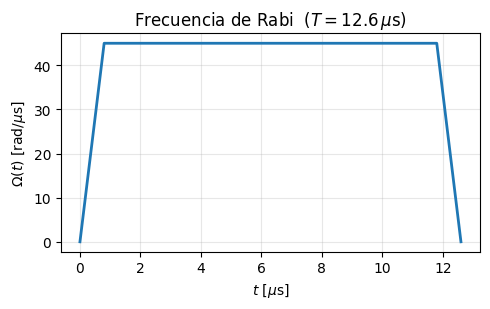

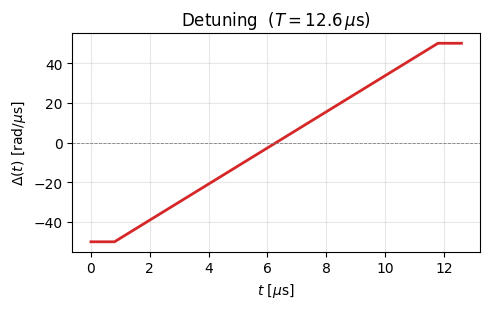

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del pulso ---
sweep_time = 11.0          # µs, duración del tramo central
durations = [0.8, sweep_time, 0.8]
T_total = sum(durations)   # duración total del pulso

# Valores de ejemplo (rad/µs); ajusta si quieres reflejar otro caso
delta_end  = 50.0
omega_max  = 0.9 * delta_end

rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

# Eje temporal acumulado
t = np.concatenate(([0.0], np.cumsum(durations)))

# --- Figura 1: Frecuencia de Rabi ---
fig1, ax1 = plt.subplots(figsize=(5, 3.2))
ax1.plot(t, rabi_amplitude_values, color="tab:blue", lw=2)
ax1.set_xlabel(r"$t$ [$\mu$s]")
ax1.set_ylabel(r"$\Omega(t)$ [rad/$\mu$s]")
ax1.set_title(rf"Frecuencia de Rabi  ($T = {T_total:.1f}\,\mu$s)")
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1.savefig("pulso_rabi.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Figura 2: Detuning ---
fig2, ax2 = plt.subplots(figsize=(5, 3.2))
ax2.plot(t, rabi_detuning_values, color="tab:red", lw=2)
ax2.set_xlabel(r"$t$ [$\mu$s]")
ax2.set_ylabel(r"$\Delta(t)$ [rad/$\mu$s]")
ax2.set_title(rf"Detuning  ($T = {T_total:.1f}\,\mu$s)")
ax2.axhline(0, color="gray", lw=0.6, ls="--")
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig("pulso_detuning.png", dpi=200, bbox_inches="tight")
plt.show()

# Definición del grafo (matriz Q)
Distingo entre `Q` y `Q_exacta` porque la interacción entre aristas separadas por más de un nodo a veces altera la resolución del problema

### $P_3$

In [81]:
#Grafo P_3 (cadena de 3 nodos, 2 aristas)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P3")

Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_func = Q_func_P3

Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func = Q_exacta_func_P3

def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### Grafo $P_4$

In [84]:
#Grafo P_4 (cadena de 4 nodos)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P4")

Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_func = Q_func_P4

Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])
Q_exacta_func = Q_exacta_func_P4
# 
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


### $P_5$

In [86]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.5*A_solucion

nombre_grafo = str("P5")

Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_func = Q_func_P5

Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P5

def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### $P_5 \ modificado$ 

In [89]:
A_solucion=20
B_solucion=0.5*A_solucion
C_solucion=0.1*A_solucion

nombre_grafo = str("P5 modificado")

Q_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -4*B+C, A+2*B, 0,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  0     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_func = Q_func_P5mod


Q_exacta_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      B     ],
    [0,      -4*B+C, A+2*B, B,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  B     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P5mod


#C6 = 2 * np.pi * 862690
#d_init = (C6 / A) ** (1/6)

def x0_func_P5mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [1.5 * d, d  ],  # e4
    ]).flatten()

### $P_6$

In [136]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6")

Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P6

Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P6


def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
    ]).flatten()

### $P_6 \ modificado$

In [95]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6 modificado")

Q_exacta_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      B     ],
    [0,       0,    -4*B+C, A+2*B,  B,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  B     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

Q_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,  0,     0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -4*B+C, A+2*B,  0,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  0     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

def x0_func_P6mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * 2*d,    0.0],  # e0
        [1 * 2*d,    0.0],  # e1
        [2 * 2*d,    0.0],  # e2
        [3 * 2*d,    0.0],  # e3
        [4 * 2*d,    0.0],  # e4
        [2.5 * 2*d,  2*d  ],  # e5
    ]).flatten()



### Grafo $P_7$

In [66]:
A_solucion=50
B_solucion=15
C_solucion=5

nombre_grafo = str("P7")

Q_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,   0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P7

Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, B,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  B,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,  B   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func_P7 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     -3*B+C, A+2*B,  0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B,  0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P7

def x0_func_P7(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
    ]).flatten()

### Grafo $P_8$

In [48]:
A_solucion=50
B_solucion=15   
C_solucion=5


nombre_grafo = str("P8")

Q_func_P8 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0,     0   ],
    [0,      -3*B+C, A+2*B, 0,      0,      0,     0   ],
    [0,      0,     -3*B+C, A+2*B, 0,      0,      0   ],
    [0,      0,     0,     -3*B+C, A+2*B, 0,       0   ],
    [0,      0,     0,     0,     -3*B+C, A+2*B,   0   ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P8

Q_exacta_func_P8 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0,      0  ],
    [0,      -3*B+C, A+2*B, B,      0,      0,      0  ],
    [0,      0,     -3*B+C, A+2*B, B,      0,       0  ],
    [0,      0,     0,     -3*B+C, A+2*B, B,        0  ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, B     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P8


def x0_func_P8(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
        [6 * d,   0.0],  # e6
    ]).flatten()

### Grado $P_9$

In [49]:
A_solucion=50
B_solucion=15  
C_solucion=5

nombre_grafo = str("P9")

Q_func_P9 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0,      0,      0     ],
    [0,      0,     -3*B+C, A+2*B, 0,      0,      0,      0     ],
    [0,      0,     0,     -3*B+C, A+2*B, 0,      0,      0     ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, 0,      0     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B, 0     ],
    [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P9

Q_exacta_func_P9 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      0,      0,      0     ],
    [0,      0,     -3*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      0,     0,     -3*B+C, A+2*B, B,      0,      0     ],
    [0,      0,     0,     0,     -3*B+C, A+2*B, B,      0     ],
    [0,      0,     0,     0,     0,     -3*B+C, A+2*B, B     ],
    [0,      0,     0,     0,     0,     0,     -3*B+C, A+2*B ],
    [0,      0,     0,     0,     0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P9


def x0_func_P9(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
        [5 * d,   0.0],  # e5
        [6 * d,   0.0],  # e6
        [7 * d,   0.0],  # e7
    ]).flatten()

### Grafo Y

In [196]:
#Grafo Y

A_solucion=50 # A partir de A =110, la simulación tarda mucho más tiempo
B_solucion=30 #0.8*A_solucion
C_solucion=10 #0.2*A_solucion

nombre_grafo = str("Y")

Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_func = Q_func_Y


Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func = Q_exacta_func_Y


def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()

### Grafo $C_4$

In [97]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4")

Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_exacta_func = Q_exacta_func_C4

Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func = Q_func_C4


def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()

### $C_4 \ modificado$ 

In [160]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4 modificado")

Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B],  # x_0=(0,1): adyacente a x_1, x_3, x_4
    [0,      -3*B+C, A+2*B, 0,     0    ],  # x_1=(1,2): adyacente a x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0    ],  # x_2=(2,3): adyacente a x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B],  # x_3=(3,0): adyacente a x_0, x_2, x_4
    [0,       0,     0,     0,    -3*B+C],  # x_4=(0,4): adyacente a x_0, x_3
])
Q_func = Q_func_C4mod


Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C4mod
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B,  0,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B,  0,   0   ],
    [0,       0,    -3*B+C, A+2*B, 0    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C4mod


def x0_func_C4mod(A, Q):
    """
    Geometría inicial: x_0, x_3, x_4 (las tres aristas incidentes en el vértice 0)
    forman un triángulo equilátero de lado d. x_1, x_2 cierran el cuadrado del ciclo.
    """
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [ 0.0,             0.0   ],  # x_0 = (0,1)
        [ d,               0.0   ],  # x_1 = (1,2)
        [ d,               d     ],  # x_2 = (2,3)
        [ 0.0,             d     ],  # x_3 = (3,0)
        [-d*np.sqrt(3)/2,  d/2   ],  # x_4 = (0,4)  -> equidista de x_0 y x_3
    ]).flatten()

### Grafo $C_5$

In [102]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5")

Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C5

Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C5



def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()

### Grafo $C_5 \ modificado$

In [176]:
A_solucion = 50
B_solucion = 0.8*A_solucion
C_solucion = 0.2*A_solucion

nombre_grafo = str("C5 modificado")

# C5 con un nodo extra (nodo 5) conectado al nodo 4 del ciclo
# Ciclo: 0-1-2-3-4-0   |   Cola: 4-5
# Grados:  0->2, 1->2, 2->2, 3->2, 4->3, 5->1
#
# Aristas (variables QUBO):
#   x_0 = (0,1)
#   x_1 = (1,2)
#   x_2 = (2,3)
#   x_3 = (3,4)
#   x_4 = (4,0)
#   x_5 = (4,5)
#
# Adyacentes en L(G): (0,1), (0,4), (1,2), (2,3), (3,4), (3,5), (4,5)

Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],  # x_0=(0,1): adyac. x_1, x_4
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],  # x_1=(1,2): adyac. x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],  # x_2=(2,3): adyac. x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],  # x_3=(3,4): adyac. x_2, x_4, x_5
    [0,       0,     0,     0,    -4*B+C, A+2*B],  # x_4=(4,0): adyac. x_0, x_3, x_5
    [0,       0,     0,     0,     0,    -3*B+C],  # x_5=(4,5): adyac. x_3, x_4
])
Q_func = Q_func_C5mod


# Q_exacta: residuos cuadráticos de H_B en pares no adyacentes en L(G).
# Pares no adyacentes y coeficientes:
#   (0,2)->B, (0,3)->B, (0,5)->B, (1,3)->B, (1,4)->B,
#   (1,5)->0, (2,4)->B, (2,5)->B
Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C5mod


def x0_func_C5mod(A, Q):
    """
    Geometría inicial: pentágono regular (x_0..x_4) de lado d centrado en
    el origen, más x_5 formando triángulo equilátero con x_3 y x_4 (las dos
    aristas incidentes en v_4 dentro del ciclo).
    """
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    pent = np.array([
        [R*np.cos(2*np.pi*k/5 + np.pi/2), R*np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ])
    # x_5 equidistante de x_3 y x_4, hacia fuera del pentágono
    p3, p4 = pent[3], pent[4]
    mid = (p3 + p4) / 2
    perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
    perp = perp / np.linalg.norm(perp)
    if np.dot(perp, mid) < 0:
        perp = -perp
    p5 = mid + perp * (d * np.sqrt(3) / 2)
    return np.vstack([pent, p5]).flatten()

### Grafo $C_6$

In [52]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C6")

# En este caso no hace falta aproximar
Q_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B,  0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B,  0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C6


# Matriz exacta
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B,  0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B,  0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])

Q_exacta_func = Q_exacta_func_C6



def x0_func_C6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 6 átomos en hexágono regular de lado d (R = d)
    return np.array([
        [d * np.cos(2*np.pi*k/6), d * np.sin(2*np.pi*k/6)]
        for k in range(6)
    ]).flatten()

### Grafo $C_7$

In [53]:
# Grafo C_7 (ciclo de 7 nodos, 7 aristas)

nombre_grafo = str("C7")

# Matriz truncada (solo adyacencia directa)
Q_func_C7 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0,      0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0,      0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C7

# Matriz exacta (incluye términos a segundos vecinos B)
Q_exacta_func_C7 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      0,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      0,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B, B,      0,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B, B,      0    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C7

def x0_func_C7(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    
    # 7 átomos en heptágono regular de lado d. 
    # Radio R garantizando que la cuerda (lado) sea d
    R = d / (2 * np.sin(np.pi / 7))
    
    return np.array([
        [R * np.cos(2*np.pi*k/7), R * np.sin(2*np.pi*k/7)]
        for k in range(7)
    ]).flatten()

### Grafo $K_{1'3}$

In [189]:
A = A_solucion = 45
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.3*A_solucion

nombre_grafo = str("K_3")

Q_exacta_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_K13

Q_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func = Q_func_K13


def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

### Grafo $K_{1'4}$ *(no es posible representarlo correctamente)*

In [29]:
Q_exacta_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_exacta_func = Q_exacta_func_K_14

Q_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_func = Q_func_K_14

# Resolución para 1 caso

---Solución clásica: 
 [('010001', np.float64(-54.6)), ('001010', np.float64(-54.599999999999994)), ('010010', np.float64(-54.599999999999994)), ('010100', np.float64(-54.599999999999994)), ('100100', np.float64(-54.599999999999994)), ('101001', np.float64(-50.400000000000006))] 



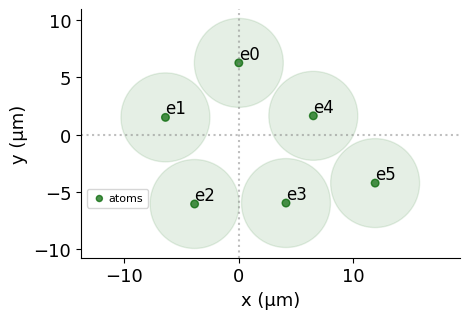

Coordenadas optimizadas:
[[ 5.10394944e-17  6.27397204e+00]
 [-6.40879243e+00  1.51341589e+00]
 [-3.86321304e+00 -6.05332329e+00]
 [ 4.11995898e+00 -5.96927987e+00]
 [ 6.50736041e+00  1.64878447e+00]
 [ 1.19068095e+01 -4.22645449e+00]]


-6408792.425258888 11906809.531424038 -6053323.290662613 6273972.044853423


A=21, B=10.5, C=4.2  →  P(éxito) = 0.44%
  Soluciones válidas: ['010001']  (E = -54.600)
  Conteos solución:   44 / 10000


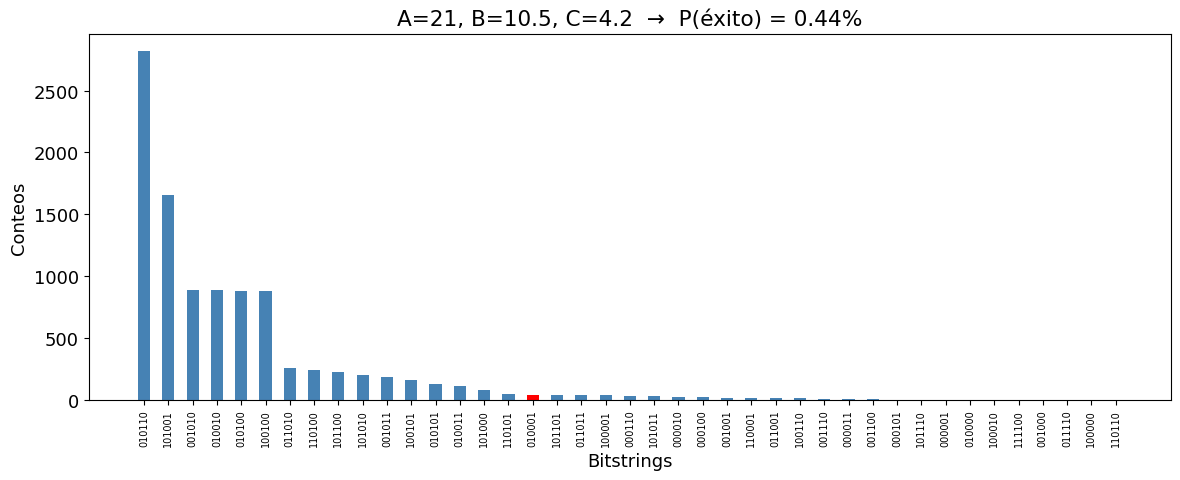

In [178]:
for k in [0.95]:
    A = A_solucion = 21#= 50 #= 10
    B = B_solucion = 0.5*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.2*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func_C5mod) #, x0_func=x0_func_P6mod)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

    A_values = [A]
    B_values = [B]
    C_values = [C]


#  for k in [0.95]:
#     A = A_solucion = 21#= 50 #= 10
#     B = B_solucion = 0.5*A_solucion #= k*A_solucion#= 0.4*A_solucion
#     C = C_solucion = 0.2*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion

#     sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

#     Q       = Q_func(A, B, C)
#     geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func_C4mod) #, x0_func=x0_func_P6mod)
#     prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

#     A_values = [A]
#     B_values = [B]
#     C_values = [C]



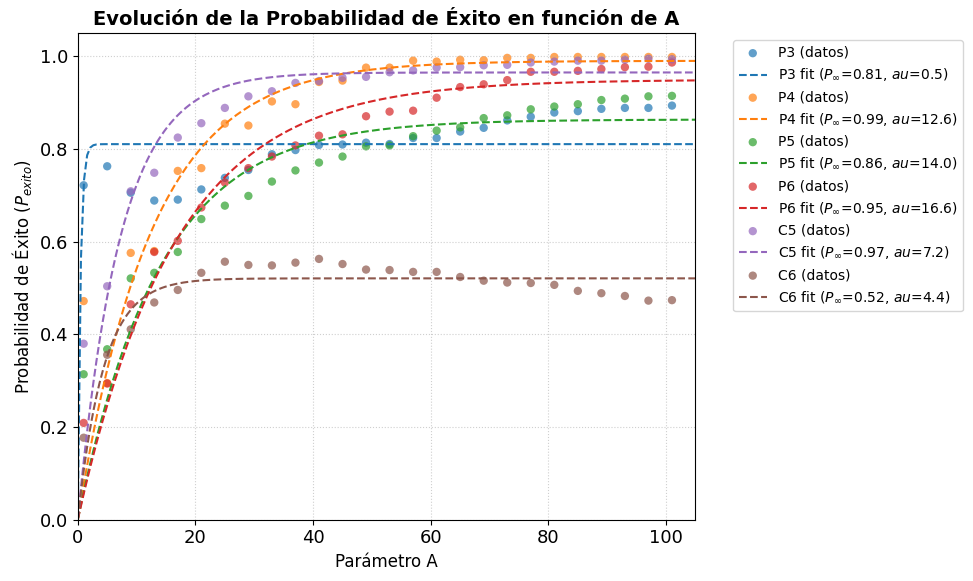

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Definición del modelo para el ajuste
def modelo_exp(A, P_inf, tau):
    return P_inf * (1.0 - np.exp(-A / tau))

# 2. Valores de A correspondientes al barrido numérico
A_values = np.array([
    1.0, 5.0, 9.0, 13.0, 17.0, 21.0, 25.0, 29.0, 33.0, 37.0, 41.0, 45.0, 49.0,
    53.0, 57.0, 61.0, 65.0, 69.0, 73.0, 77.0, 81.0, 85.0, 89.0, 93.0, 97.0, 101.0
])

# 3. Diccionario con las probabilidades de éxito fijadas (P_exito)
# Nota: Para C6 se han integrado los resultados correctos calculados de forma independiente.
resultados_P_exito = {
    "P3": np.array([
        0.722, 0.763, 0.706, 0.689, 0.691, 0.713, 0.738, 0.755, 0.789, 0.798, 0.809,
        0.810, 0.814, 0.811, 0.824, 0.824, 0.838, 0.846, 0.862, 0.870, 0.879, 0.882,
        0.887, 0.889, 0.889, 0.894
    ]),
    "P4": np.array([
        0.472, 0.295, 0.576, 0.580, 0.753, 0.759, 0.855, 0.851, 0.903, 0.897, 0.945,
        0.948, 0.976, 0.976, 0.991, 0.989, 0.993, 0.992, 0.997, 0.997, 0.999, 0.999,
        0.999, 0.999, 0.999, 0.999
    ]),
    "P5": np.array([
        0.314, 0.368, 0.521, 0.533, 0.578, 0.649, 0.678, 0.699, 0.730, 0.754, 0.771,
        0.784, 0.806, 0.808, 0.828, 0.840, 0.847, 0.867, 0.873, 0.886, 0.892, 0.897,
        0.906, 0.909, 0.914, 0.915
    ]),
    "P6": np.array([
        0.209, 0.294, 0.465, 0.578, 0.602, 0.674, 0.728, 0.759, 0.784, 0.808, 0.829,
        0.832, 0.871, 0.881, 0.883, 0.911, 0.934, 0.940, 0.949, 0.967, 0.967, 0.969,
        0.973, 0.977, 0.978, 0.987
    ]),
    "C5": np.array([
        0.380, 0.504, 0.709, 0.749, 0.825, 0.856, 0.889, 0.914, 0.925, 0.943, 0.947,
        0.954, 0.956, 0.966, 0.970, 0.976, 0.977, 0.981, 0.982, 0.987, 0.989, 0.991,
        0.991, 0.993, 0.995, 0.994
    ]),
    "C6": np.array([
        0.177, 0.356, 0.411, 0.469, 0.496, 0.533, 0.557, 0.550, 0.549, 0.555, 0.563,
        0.552, 0.540, 0.539, 0.535, 0.535, 0.524, 0.516, 0.512, 0.511, 0.507, 0.494,
        0.489, 0.483, 0.473, 0.474
    ])
}

# 4. Generación de gráficos y ajuste de curvas
plt.figure(figsize=(10, 6))

# Paleta de colores consistente
colores = {"P3": "#1f77b4", "P4": "#ff7f0e", "P5": "#2ca02c", "P6": "#d62728", "C5": "#9467bd", "C6": "#8c564b"}

for nombre, p_exito in resultados_P_exito.items():
    color = colores.get(nombre, None)
    
    # Dibujar los puntos experimentales medidos
    plt.scatter(A_values, p_exito, label=f"{nombre} (datos)", color=color, alpha=0.7, edgecolors='none')
    
    # Ajuste mediante curve_fit (evitando divisiones por cero con p0 inicial razonable)
    try:
        popt, _ = curve_fit(modelo_exp, A_values, p_exito, p0=[1.0, 20.0], maxfev=5000)
        A_fit = np.linspace(0.01, 105, 200)
        plt.plot(A_fit, modelo_exp(A_fit, *popt), color=color, linestyle="--", 
                 label=f"{nombre} fit ($P_\infty$={popt[0]:.2f}, $\tau$={popt[1]:.1f})")
    except RuntimeError:
        # En caso de que algún grafo no converja, une los puntos con línea continua para no perder la visualización
        plt.plot(A_values, p_exito, color=color, linestyle="-", alpha=0.5, label=f"{nombre} (sin ajuste)")

# Configuración del estilo del eje y etiquetas
plt.title("Evolución de la Probabilidad de Éxito en función de A", fontsize=14, fontweight='bold')
plt.xlabel("Parámetro A", fontsize=12)
plt.ylabel("Probabilidad de Éxito ($P_{exito}$)", fontsize=12)
plt.xlim(0, 105)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()

In [198]:
# === Barrido en A para UN solo grafo ===
# Cambia las funciones del grafo aquí:
nombre_grafo = "Y"
Qf  = Q_func_Y
Qef = Q_exacta_func_Y
x0f = x0_func_Y_horizontal

# Parámetros del barrido
ratio_B   = 0.7
ratio_C   = 0.35
A_values  = np.arange(1, 105, 4)
T_barrido = 5.0
n_intentos_geom = 5
n_shots   = 1000

C6_dev = pulser.DigitalAnalogDevice.interaction_coeff

def _residual(Q, coords):
    iu = np.triu_indices(len(Q), k=1)
    new_Q = squareform(C6_dev / pdist(coords)**6)
    return np.linalg.norm(new_Q[iu] - Q[iu])

resultados_A = {}
tiempos_A    = {}
residuos_A   = {}

print(f"=== Barrido en A para {nombre_grafo}  "
      f"(B/A={ratio_B}, C/A={ratio_C}, T_barrido={T_barrido} µs) ===\n")
print(f"{'A':>5} {'B':>7} {'C':>7} {'P_exito':>9} {'T_sim [s]':>10} {'residuo':>10}")
print("-" * 55)

t_total = time.time()
for A in A_values:
    B, C = ratio_B * A, ratio_C * A
    Q       = Qf(A, B, C)
    Q_exact = Qef(A, B, C)

    if np.any(-np.diag(Q) <= 0):
        resultados_A[A] = np.nan
        tiempos_A[A]    = np.nan
        residuos_A[A]   = np.nan
        print(f"{A:5.1f} {B:7.2f} {C:7.2f} {'NaN (diag>0)':>9}")
        continue

    sort_zipped = resolucion_clasica(Q_exact)

    # --- Búsqueda robusta de geometría ---
    candidatos = []
    try:
        g, c = construir_geometria(Q, seed=0, plot=False, x0_func=x0f)
        candidatos.append((_residual(Q, c), g, c))
    except Exception as e:
        print(f"  {nombre_grafo} A={A} (x0_func): {e}")

    for s in range(n_intentos_geom):
        try:
            g, c = construir_geometria(Q, seed=s, plot=False, x0_func=None)
            candidatos.append((_residual(Q, c), g, c))
        except Exception:
            pass

    if not candidatos:
        resultados_A[A] = np.nan
        tiempos_A[A]    = np.nan
        residuos_A[A]   = np.nan
        print(f"{A:5.1f} {B:7.2f} {C:7.2f} {'NaN (geom)':>9}")
        continue

    mejor_res, mejor_geom, _ = min(candidatos, key=lambda x: x[0])

    # --- Simulación ---
    try:
        t0 = time.time()
        prob, _ = resolver_qubo(Q, mejor_geom, sort_zipped,
                                A, B, C,
                                sweep_time=T_barrido,
                                plot=False, n_shots=n_shots)
        t_sim = time.time() - t0
        resultados_A[A] = prob
        tiempos_A[A]    = t_sim
        residuos_A[A]   = mejor_res
        print(f"{A:5.1f} {B:7.2f} {C:7.2f} {prob:9.3f} {t_sim:10.2f} {mejor_res:10.3f}")
    except RuntimeError as e:
        print(f"  {nombre_grafo} A={A}: {e}")
        resultados_A[A] = np.nan
        tiempos_A[A]    = np.nan
        residuos_A[A]   = mejor_res
        print(f"{A:5.1f} {B:7.2f} {C:7.2f} {'NaN (sim)':>9}")

print(f"\n=== Tiempo total: {time.time()-t_total:.1f} s ===")

=== Barrido en A para Y  (B/A=0.7, C/A=0.35, T_barrido=5.0 µs) ===

    A       B       C   P_exito  T_sim [s]    residuo
-------------------------------------------------------
  1.0    0.70    0.35     0.294       0.04      2.401
  5.0    3.50    1.75     0.299       0.04     12.003
  9.0    6.30    3.15     0.364       0.05     21.606
 13.0    9.10    4.55     0.563       0.09     31.209
 17.0   11.90    5.95     0.600       0.09     40.811
 21.0   14.70    7.35     0.730       0.10     50.414
 25.0   17.50    8.75     0.770       0.14     60.017
 29.0   20.30   10.15     0.791       0.11     69.619
 33.0   23.10   11.55     0.848       0.16     79.222
 37.0   25.90   12.95     0.854       0.16     88.825
 41.0   28.70   14.35     0.892       0.17     98.427
 45.0   31.50   15.75     0.910       0.21    108.030
 49.0   34.30   17.15     0.934       0.20    117.633
 53.0   37.10   18.55     0.957       0.24    127.235
 57.0   39.90   19.95     0.962       0.25    136.838
 61.0   42.7

# Barrido en A para varios grafos

In [162]:
# Barrido en A para varios grafos
# Mantenemos B/A y C/A fijos en valores razonables (Lucas 2014: B/A ~ 0.5, C/A ~ 0.2)
from scipy.optimize import curve_fit

def modelo_exp(A, P_inf, tau):
    return P_inf * (1.0 - np.exp(-A / tau))


ratio_B = 0.5
ratio_C = 0.2

A_values = np.arange(0.01, 105, 10)  
n_repeticiones = 3  

resultados_A = {}  
tiempos_A = {} 

Q_func_g = Q_func
Q_exacta_func_g = Q_exacta_func

grafos = {
    "P3": (Q_func_P3, Q_exacta_func_P3, x0_func_P3),
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),  # Este sale bien pero me da pereza explicarlo
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
#    "P7": (Q_func_P7, Q_exacta_func_P7, x0_func_P7),
#    "P8": (Q_func_P8, Q_exacta_func_P8, x0_func_P8),
#    "P9": (Q_func_P9, Q_exacta_func_P9, x0_func_P9)
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),  # Este sale con menos probabilidad
#    "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),
#    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
    "C6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),      # Sale mal por alguna razón
#    "K_": (Q_func_K_13, Q_exacta_func_K_13, x0_func_K13),
}



for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()
    for A in A_values:
        B = ratio_B * A
        C = ratio_C * A
        
        Q = Q_func_g(A, B, C)
        Q_exacta = Q_exacta_func_g(A, B, C)
        
        diag = -np.diag(Q)
        if np.any(diag <= 0):
            resultados_A[(nombre, A)] = [np.nan]
            tiempos_A[(nombre, A)] = [np.nan]
            continue
        
        sort_zipped = resolucion_clasica(Q_exacta)
        
        probs = []
        tiempos = []
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=11,
                                        plot=False, n_shots=1000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  A={A}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)
        
        resultados_A[(nombre, A)] = probs
        tiempos_A[(nombre, A)] = tiempos

    fin_grafo = time.time()
    print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")


=== El grafo P3 ha tardado en ejecutarse 4.48 segundos ===

=== El grafo P4 ha tardado en ejecutarse 5.16 segundos ===

=== El grafo P5 ha tardado en ejecutarse 8.52 segundos ===

=== El grafo P6 ha tardado en ejecutarse 10.19 segundos ===

=== El grafo C5 ha tardado en ejecutarse 13.44 segundos ===

=== El grafo C6 ha tardado en ejecutarse 17.41 segundos ===


  P3: R²=0.9686, R²_adj=0.9607, χ²_red=178.16
  P4: R²=0.9964, R²_adj=0.9955, χ²_red=7.84
  P5: R²=0.9735, R²_adj=0.9669, χ²_red=9.63
  P6: R²=0.7011, R²_adj=0.6263, χ²_red=4052.29
  C5: R²=0.9545, R²_adj=0.9431, χ²_red=49.91
  C6: R²=0.9895, R²_adj=0.9869, χ²_red=6.61


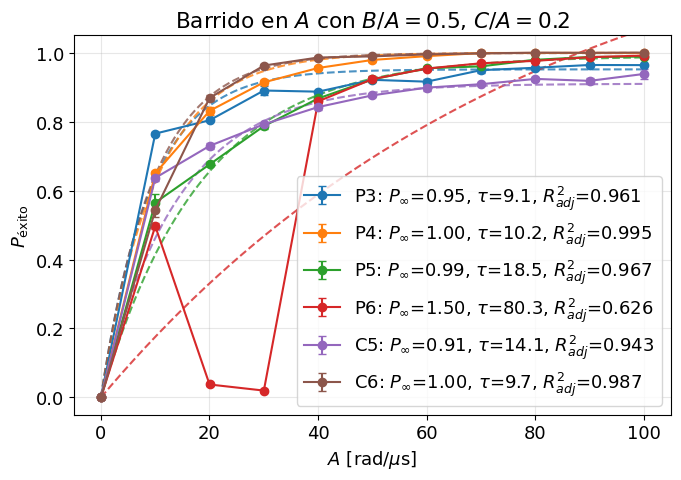

In [163]:
plt.figure(figsize=(7, 5))
A_fino = np.linspace(0, A_values.max(), 400)  
ajustes = {}                               

for nombre in grafos.keys():
    medias = np.array([np.nanmean(resultados_A[(nombre, A)]) for A in A_values])
    stds   = np.array([np.nanstd(resultados_A[(nombre, A)])  for A in A_values])

    # Filtramos NaN antes de ajustar
    mask = ~np.isnan(medias)
    A_fit, y_fit, s_fit = A_values[mask], medias[mask], stds[mask]
    # Evitamos sigma=0 (rompe curve_fit con absolute_sigma=True)
    s_pos = s_fit[s_fit > 0]
    s_fit = np.where(s_fit > 0, s_fit, np.nanmean(s_pos) if s_pos.size > 0 else 1e-3)

    # Ajuste con (0,0) impuesto por la forma del modelo
    popt = None
    etiqueta = nombre
    try:
        popt, pcov = curve_fit(
            modelo_exp, A_fit, y_fit,
            p0=[1.0, 20.0],                 # estimación inicial: satura en 1, tau ~ 20
            sigma=s_fit, absolute_sigma=True,
            bounds=([0, 1e-3], [1.5, 1e4]),
            maxfev=10000,
        )
        perr = np.sqrt(np.diag(pcov))

        # --- Bondad del ajuste ---
        y_pred = modelo_exp(A_fit, *popt)
        residuos = y_fit - y_pred
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
        R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        n, k = len(y_fit), len(popt)
        R2_adj = 1 - (1 - R2) * (n - 1) / (n - k - 1) if (n - k - 1) > 0 else np.nan
        dof = max(n - k, 1)
        chi2_red = np.sum((residuos / s_fit)**2) / dof

        ajustes[nombre] = (popt, perr, R2_adj, chi2_red)
        etiqueta = (rf'{nombre}: $P_\infty$={popt[0]:.2f}, '
                    rf'$\tau$={popt[1]:.1f}, $R^2_{{adj}}$={R2_adj:.3f}')
        print(f'  {nombre}: R²={R2:.4f}, R²_adj={R2_adj:.4f}, χ²_red={chi2_red:.2f}')
    except (RuntimeError, ValueError) as e:
        print(f'Ajuste falló para {nombre}: {e}')

    line = plt.errorbar(A_values, medias, yerr=stds, marker='o', capsize=3, label=etiqueta)
    if popt is not None:
        plt.plot(A_fino, modelo_exp(A_fino, *popt),
                 '--', color=line[0].get_color(), alpha=0.8)

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.title(rf'Barrido en $A$ con $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()

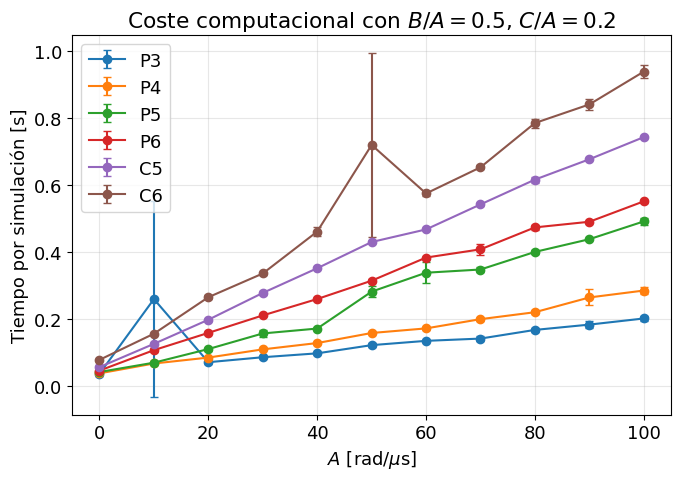

In [164]:
plt.figure(figsize=(7, 5))
for nombre in grafos.keys():
    medias = [np.nanmean(tiempos_A[(nombre, A)]) for A in A_values]
    stds   = [np.nanstd(tiempos_A[(nombre, A)])  for A in A_values]
    plt.errorbar(A_values, medias, yerr=stds, marker='o', label=nombre, capsize=3)

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.title(rf'Coste computacional con $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
#plt.yscale('log')  # Recomendado: el coste crece rápido con A (rigidez del solver)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# Heatmap variación B,C

---Solución clásica: 
 [('00101', np.float64(-110.0)), ('01001', np.float64(-110.0)), ('01010', np.float64(-110.0)), ('10100', np.float64(-110.0)), ('00010', np.float64(-92.5)), ('10000', np.float64(-92.5))] 

A=50: 2.98 s


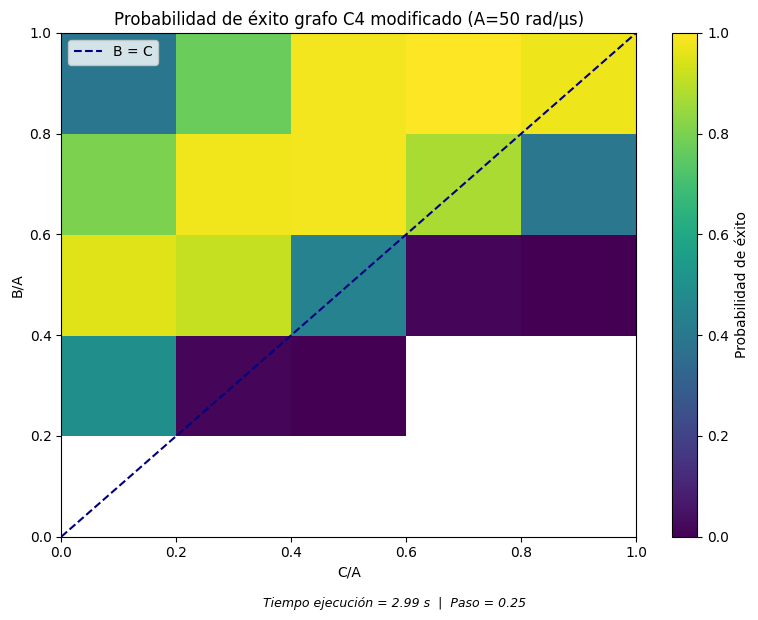

In [130]:
A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
x0_func=x0_func_C4mod


sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [50]
#A_values = np.arange(5, 5.1, 0.5)

resultados = {}
# He cambiado a continuación A por n_shots. Antes tenía n_shots=1000
for A in A_values:
    #B_values = np.arange(0.37*A, 0.42*A, 0.02*A)
    #C_values = np.arange(0.01*A, 0.5*A, 0.02*A)
    #    
    #B_values = np.arange(0.01*A, 1.12*A, 0.08*A)
    #C_values = np.arange(0.01*A, 1.12*A, 0.08*A)

    paso = 0.25
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casoscon detuning negativo
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan
                continue
            try:
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, sweep_time=0.5, plot=False, n_shots=2000)
                resultados[(A, B, C)] = prob
            except Exception:
                # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                # se asigna NaN y el barrido continúa con el siguiente punto.
                resultados[(A, B, C)] = np.nan

            #geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
            #prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
            #resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.figtext(0.5, -0.02,
            f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
            ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()